# Indonesia Inequality Project: Initial EDA

This notebook starts the second part of the project: exploratory data analysis on the currently ingested annual datasets.

Scope for this notebook:

- inspect processed CSV coverage
- visualize available World Bank-backed fields
- make BPS-related gaps visible
- avoid modeling, regressions, causal claims, or narrative conclusions

The plotting style uses `plotnine`, a Python implementation of a ggplot2-like grammar of graphics.

In [31]:
from pathlib import Path

import pandas as pd
from plotnine import (
    ggplot, aes, geom_line, geom_point, geom_col, geom_tile, geom_hline,
    facet_wrap, labs, scale_color_manual, scale_fill_gradient, scale_fill_manual,
    scale_x_continuous, theme, theme_minimal, element_text, element_rect,
    guides, guide_legend
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

pd.options.display.max_columns = 100
pd.options.display.float_format = '{:,.3f}'.format

palette = {
    'blue': '#2F6B9A',
    'red': '#C44E52',
    'green': '#4C956C',
    'gold': '#D4A017',
    'purple': '#7D5BA6',
    'gray': '#6C757D',
    'light': '#F6F7F9',
    'dark': '#1F2933',
}

def chart_theme():
    return theme_minimal(base_size=11) + theme(
        figure_size=(10, 5.5),
        plot_title=element_text(weight='bold', size=14, color=palette['dark']),
        plot_subtitle=element_text(size=10, color=palette['gray']),
        axis_title=element_text(size=10, color=palette['dark']),
        axis_text=element_text(size=9, color=palette['dark']),
        legend_title=element_text(size=9, weight='bold'),
        legend_position='bottom',
        panel_grid_minor=element_rect(alpha=0),
    )

## Load Processed Data

Each CSV is loaded from `data/processed`. The pipeline currently gives annual rows for 2000-2024. Some cells are intentionally blank where BPS-specific sources are not yet available.

In [32]:
files = {
    'gdp': 'gdp_indonesia.csv',
    'inflation': 'inflation_indonesia.csv',
    'inequality': 'inequality_indonesia.csv',
    'poverty': 'poverty_indonesia.csv',
    'labor': 'labor_indonesia.csv',
    'cost_of_living': 'cost_of_living_indonesia.csv',
}

data = {name: pd.read_csv(DATA_DIR / filename) for name, filename in files.items()}

for name, df in data.items():
    print(f'{name:15s} rows={len(df):2d} years={int(df.year.min())}-{int(df.year.max())} columns={len(df.columns)}')

gdp             rows=25 years=2000-2024 columns=5
inflation       rows=25 years=2000-2024 columns=10
inequality      rows=25 years=2000-2024 columns=6
poverty         rows=25 years=2000-2024 columns=4
labor           rows=25 years=2000-2024 columns=8
cost_of_living  rows=25 years=2000-2024 columns=10


## Data Coverage

This view checks which dataset-year combinations contain any non-source values beyond `year`. It is a quick QA step before looking at individual indicators.

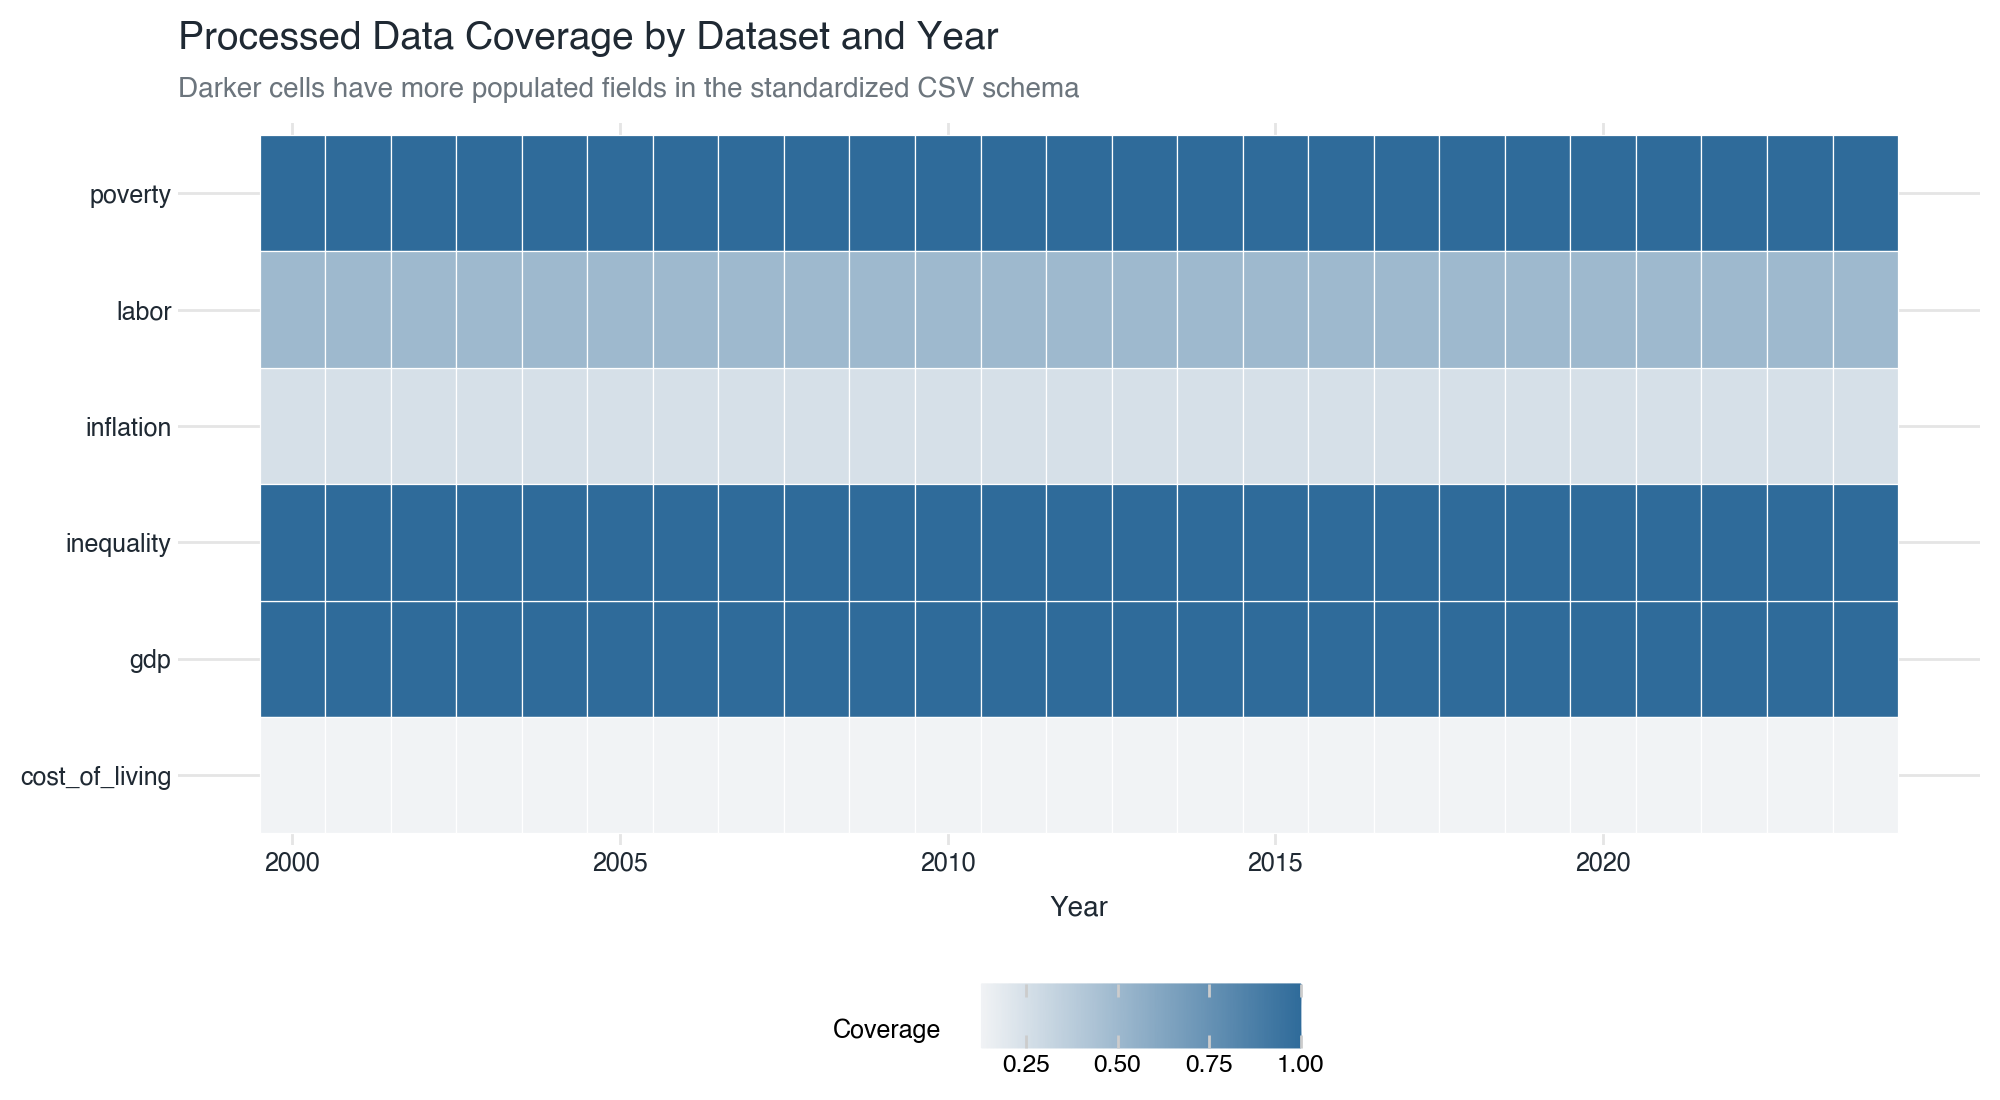

In [33]:
coverage_rows = []
for dataset, df in data.items():
    value_cols = [c for c in df.columns if c not in ['year', 'source']]
    for _, row in df.iterrows():
        present = row[value_cols].notna().sum()
        coverage_rows.append({
            'dataset': dataset,
            'year': int(row['year']),
            'available_fields': int(present),
            'total_fields': len(value_cols),
            'coverage_rate': present / len(value_cols) if value_cols else 0,
        })
coverage = pd.DataFrame(coverage_rows)

(
    ggplot(coverage, aes('year', 'dataset', fill='coverage_rate'))
    + geom_tile(color='white', size=0.25)
    + scale_fill_gradient(low='#F1F3F5', high=palette['blue'])
    + scale_x_continuous(breaks=list(range(2000, 2025, 5)))
    + labs(
        title='Processed Data Coverage by Dataset and Year',
        subtitle='Darker cells have more populated fields in the standardized CSV schema',
        x='Year', y='', fill='Coverage'
    )
    + chart_theme()
)

## Field Availability

Instead of plotting every column name, this section groups fields into three plain statuses:

- **Complete**: every year has a value
- **Partly missing**: some years have values, some years are blank
- **Empty**: no years have values yet

The empty fields are mostly BPS-dependent fields. They are present in the schema so the pipeline has a stable destination once BPS/API/manual sources are added.

In [34]:
availability_rows = []
empty_field_rows = []

for dataset, df in data.items():
    value_cols = [c for c in df.columns if c not in ['year', 'source']]
    for col in value_cols:
        missing_count = int(df[col].isna().sum())
        total_count = len(df)
        available_count = total_count - missing_count

        if missing_count == 0:
            status = 'Complete'
        elif available_count == 0:
            status = 'Empty'
            empty_field_rows.append({'dataset': dataset, 'empty_field': col})
        else:
            status = 'Partly missing'

        availability_rows.append({
            'dataset': dataset,
            'field': col,
            'status': status,
            'available_years': available_count,
            'total_years': total_count,
        })

availability = pd.DataFrame(availability_rows)
status_order = ['Complete', 'Partly missing', 'Empty']
availability['status'] = pd.Categorical(availability['status'], categories=status_order, ordered=True)

summary = (
    availability
    .groupby(['dataset', 'status'], observed=False)
    .size()
    .reset_index(name='field_count')
)

summary_table = (
    summary
    .pivot(index='dataset', columns='status', values='field_count')
    .fillna(0)
    .astype(int)
    .reset_index()
)

summary_table

status,dataset,Complete,Partly missing,Empty
0,cost_of_living,1,0,7
1,gdp,3,0,0
2,inequality,4,0,0
3,inflation,2,0,6
4,labor,3,0,3
5,poverty,2,0,0


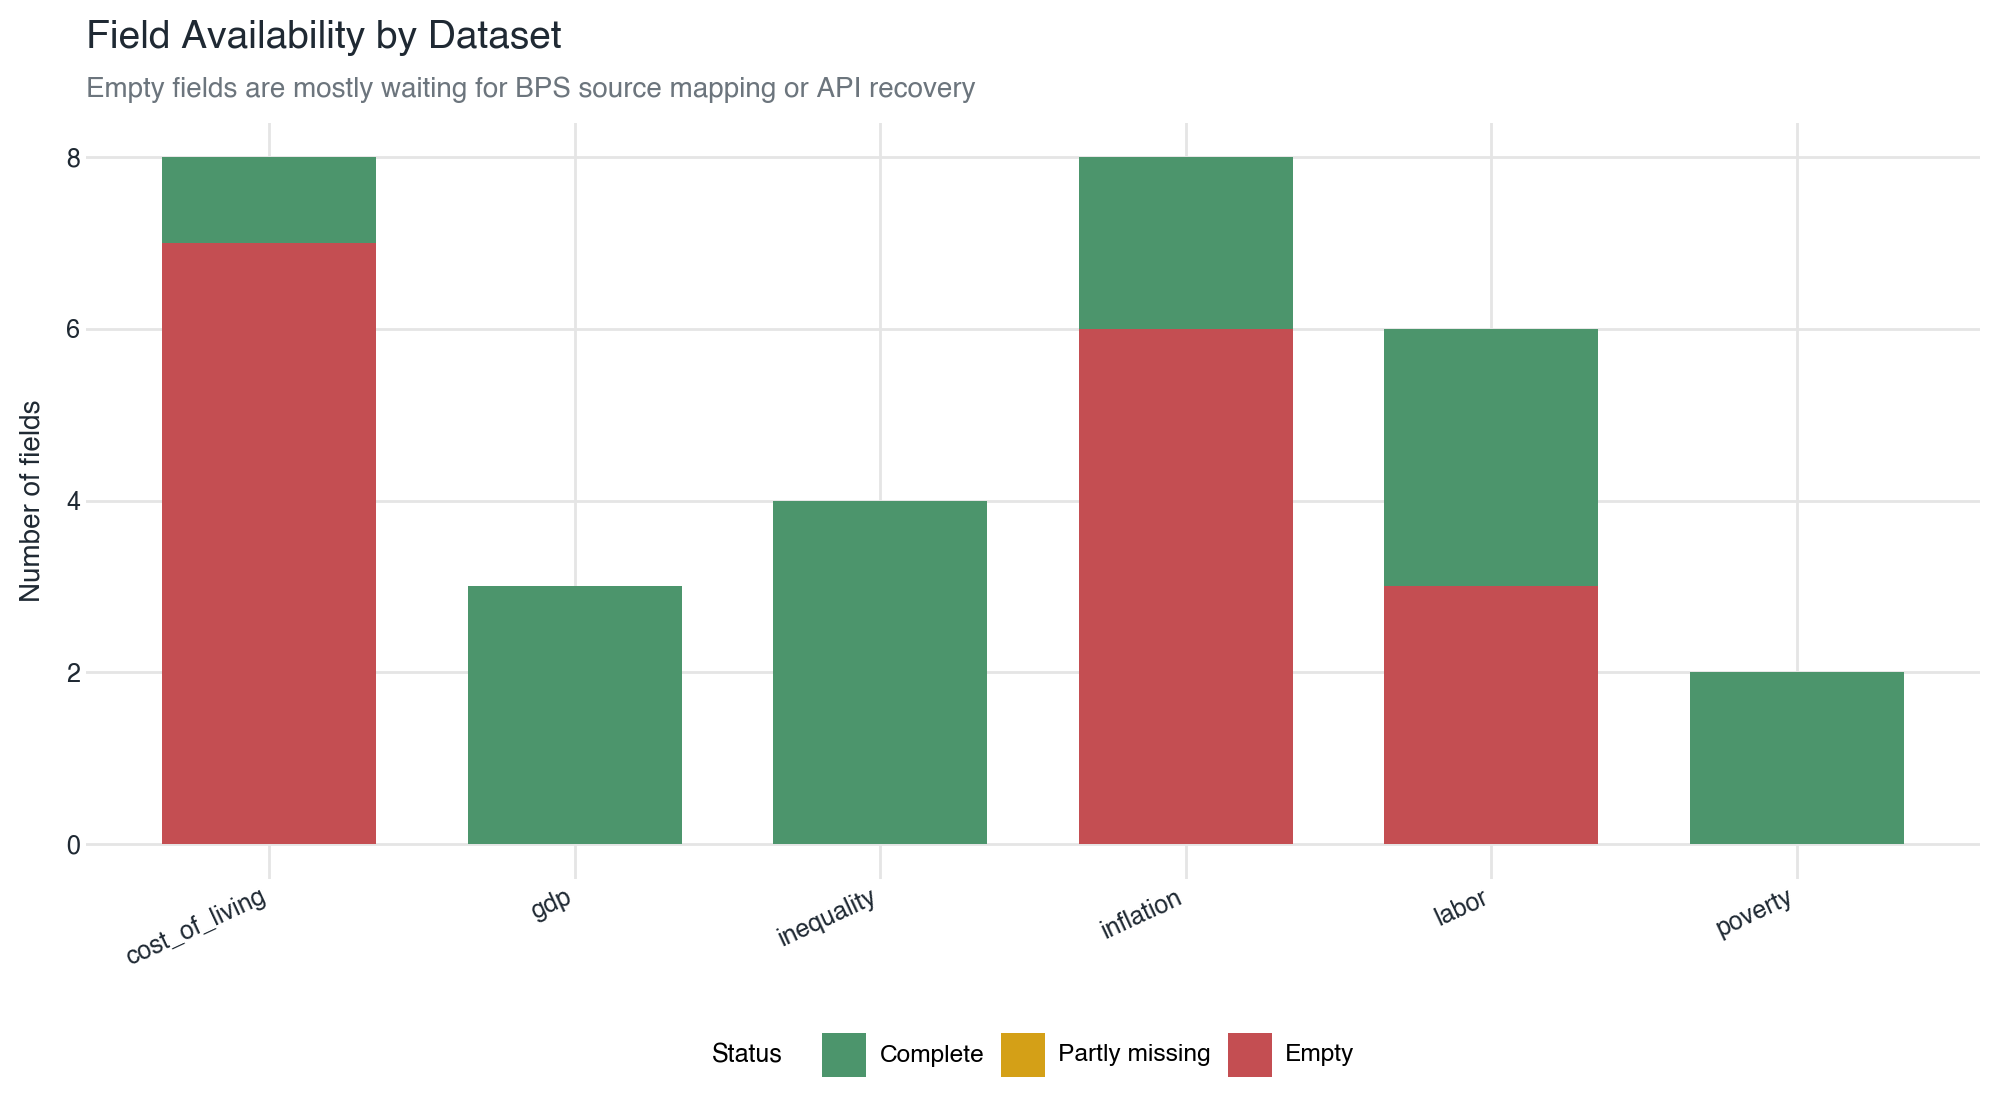

In [35]:
(
    ggplot(summary, aes('dataset', 'field_count', fill='status'))
    + geom_col(position='stack', width=0.7)
    + scale_fill_manual(values={
        'Complete': palette['green'],
        'Partly missing': palette['gold'],
        'Empty': palette['red'],
    })
    + labs(
        title='Field Availability by Dataset',
        subtitle='Empty fields are mostly waiting for BPS source mapping or API recovery',
        x='', y='Number of fields', fill='Status'
    )
    + chart_theme()
    + theme(axis_text_x=element_text(rotation=25, ha='right'))
)

### Empty Fields to Source Later

These are the fields that currently have no values in any year. They are not analysis-ready yet.

In [36]:
empty_fields = pd.DataFrame(empty_field_rows)
if empty_fields.empty:
    print('No fully empty fields.')
else:
    (
        empty_fields
        .sort_values(['dataset', 'empty_field'])
        .groupby('dataset')['empty_field']
        .apply(lambda fields: ', '.join(fields))
        .reset_index(name='fields_to_source')
    )

## GDP and Per-Capita Output

These charts inspect the available GDP growth and per-capita output fields. This is descriptive only.

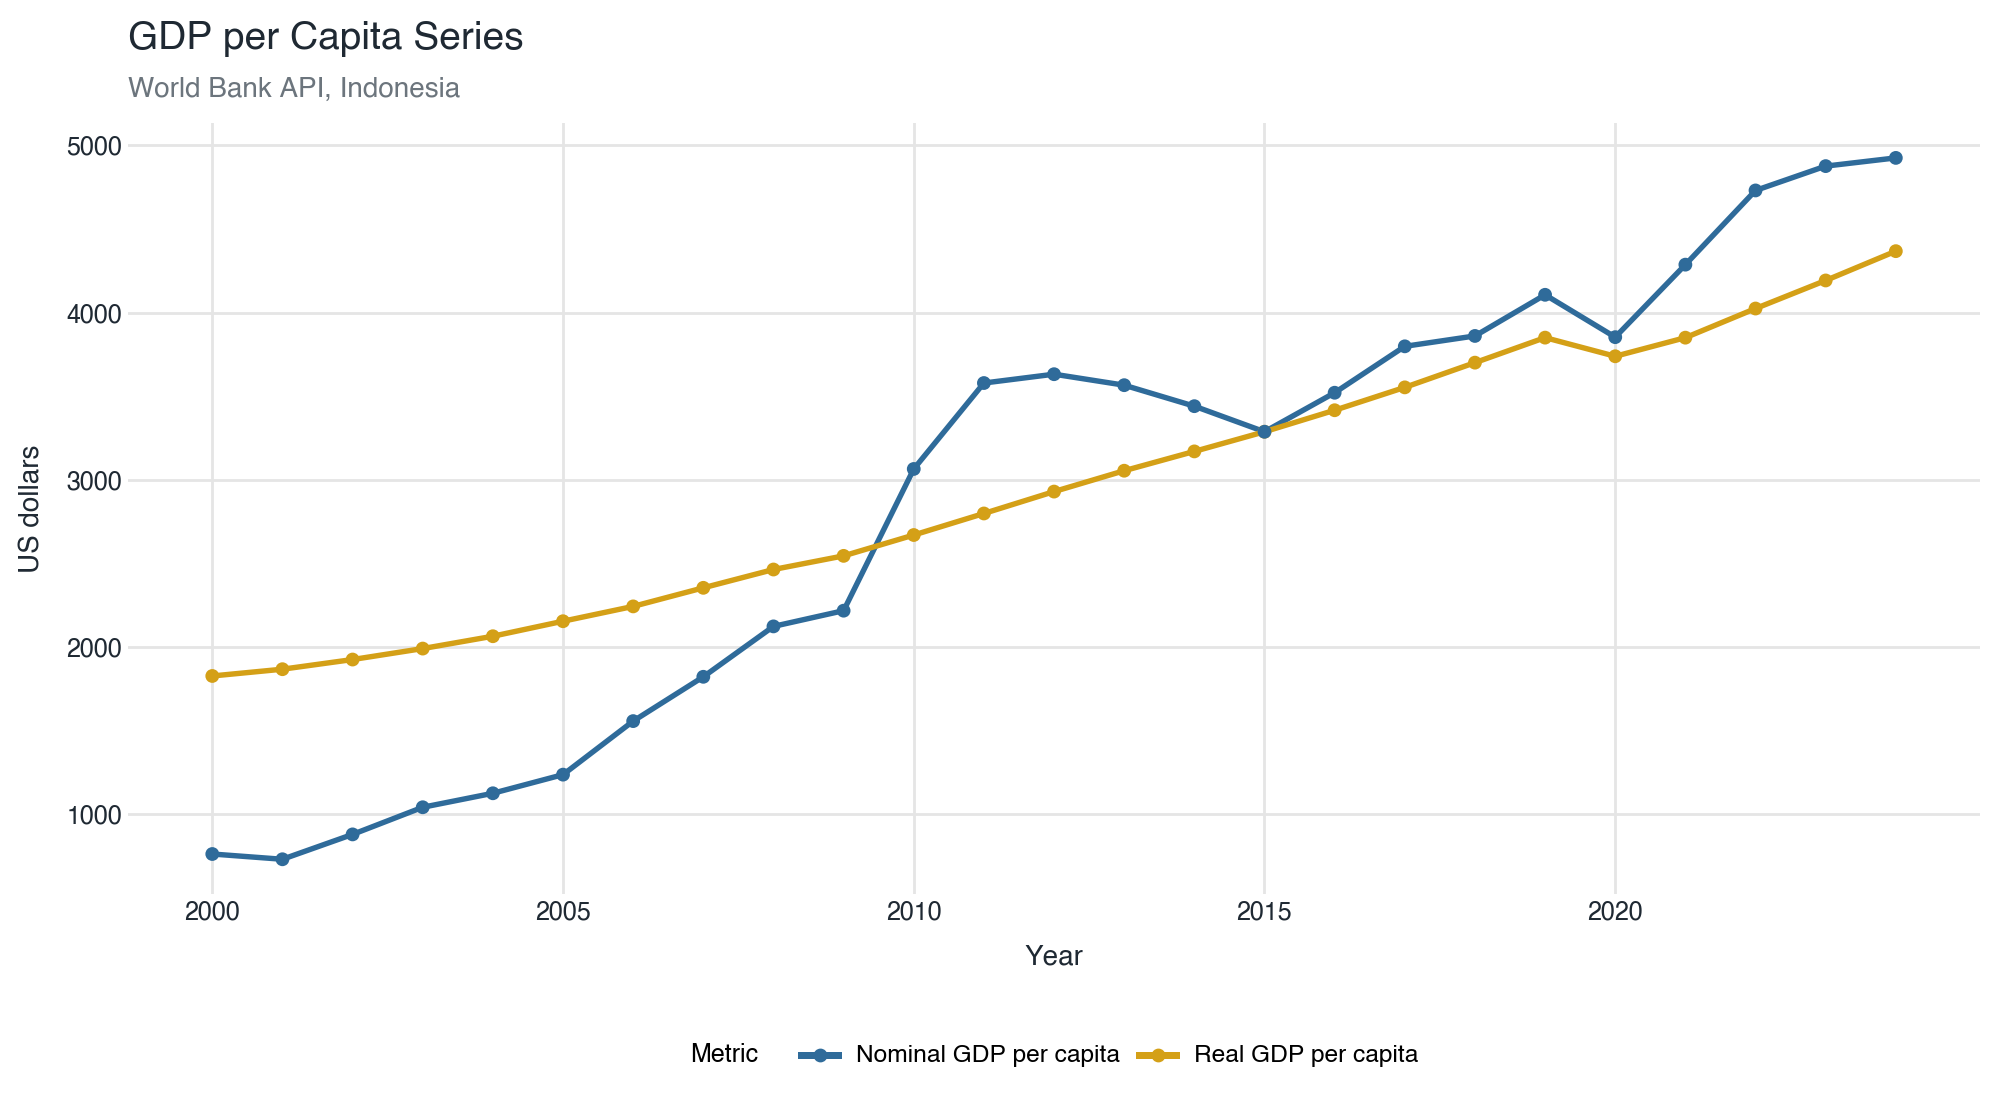

In [37]:
gdp_long = data['gdp'].melt(
    id_vars=['year'],
    value_vars=['real_gdp_per_capita', 'nominal_gdp_per_capita'],
    var_name='metric',
    value_name='value',
).dropna()

gdp_long['metric'] = gdp_long['metric'].map({
    'real_gdp_per_capita': 'Real GDP per capita',
    'nominal_gdp_per_capita': 'Nominal GDP per capita',
})

(
    ggplot(gdp_long, aes('year', 'value', color='metric'))
    + geom_line(size=1.1)
    + geom_point(size=1.8)
    + scale_color_manual(values=[palette['blue'], palette['gold']])
    + scale_x_continuous(breaks=list(range(2000, 2025, 5)))
    + labs(
        title='GDP per Capita Series',
        subtitle='World Bank API, Indonesia',
        x='Year', y='US dollars', color='Metric'
    )
    + chart_theme()
)

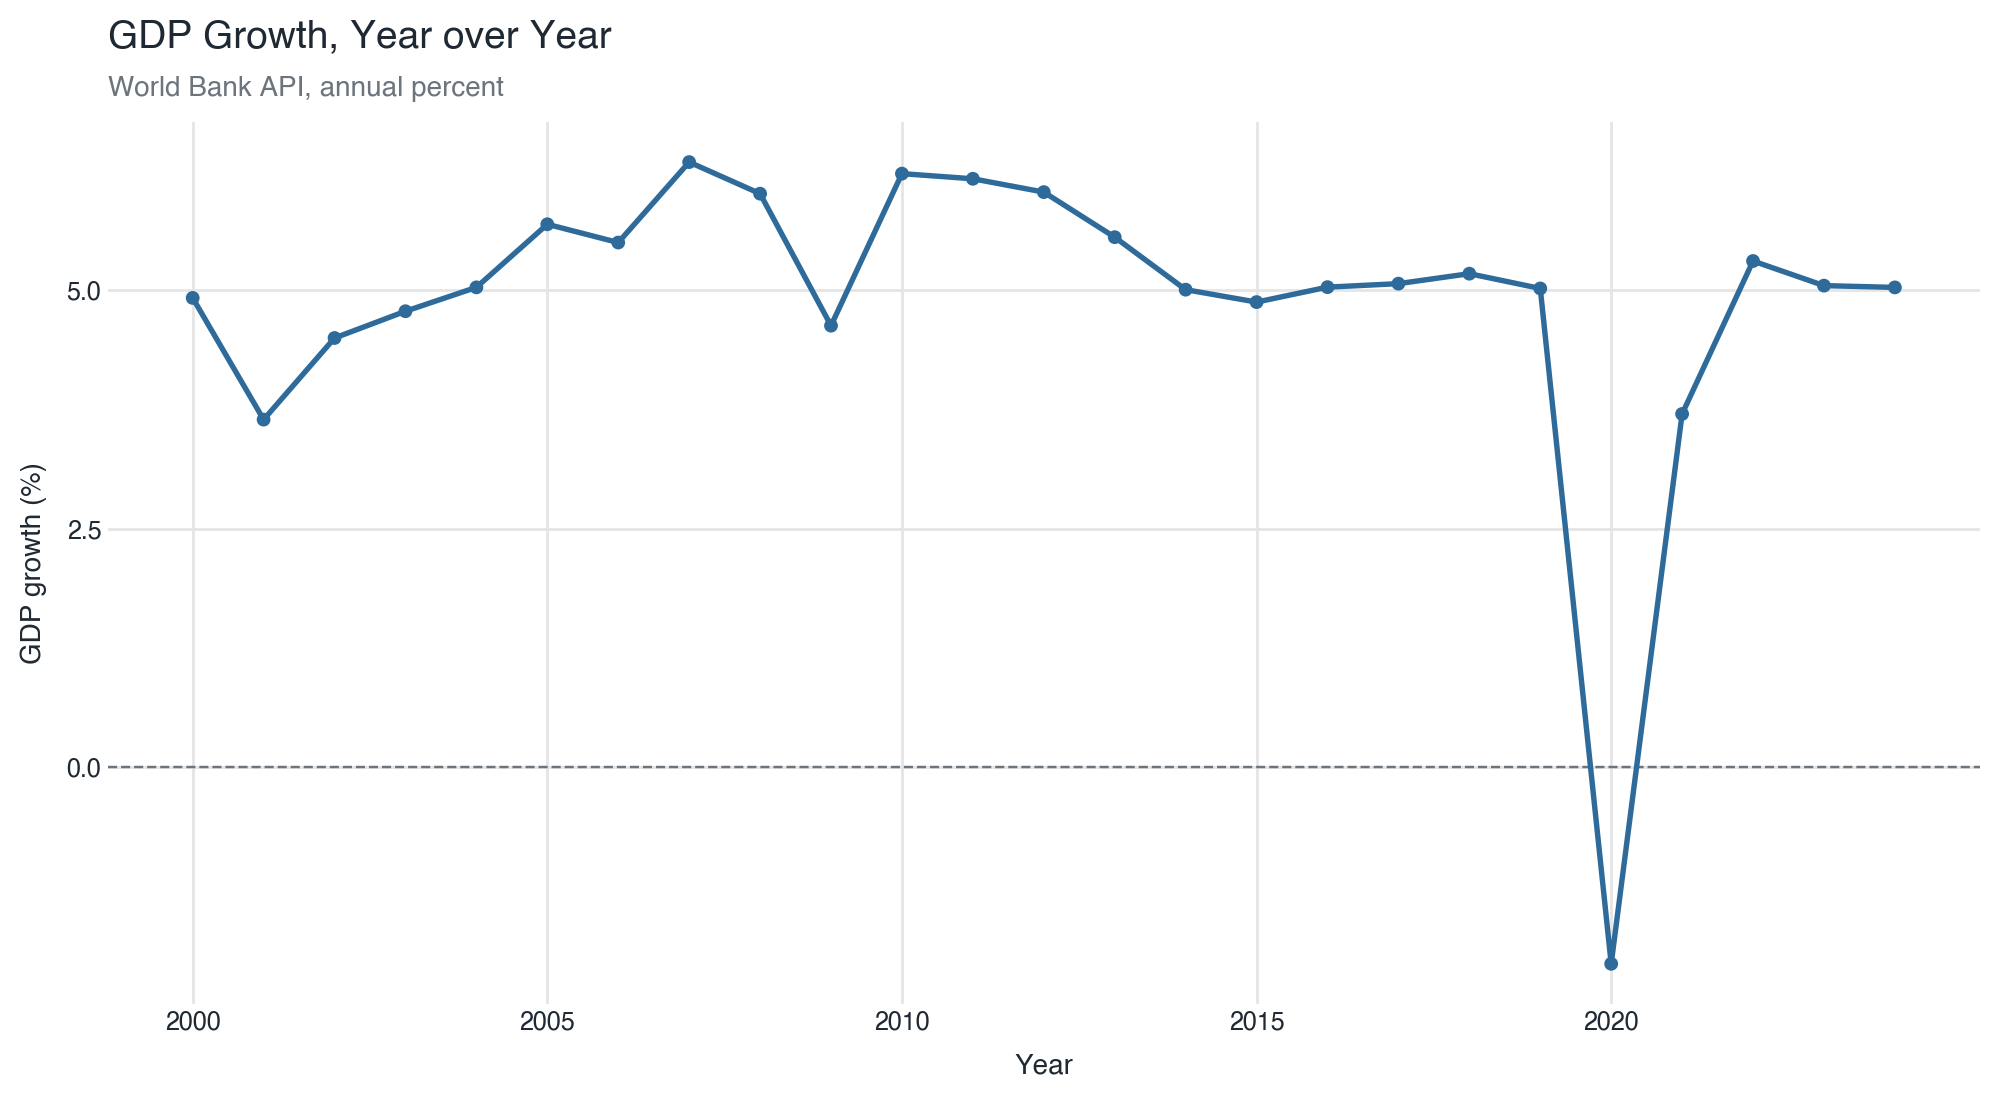

In [38]:
(
    ggplot(data['gdp'].dropna(subset=['gdp_growth']), aes('year', 'gdp_growth'))
    + geom_hline(yintercept=0, linetype='dashed', color=palette['gray'])
    + geom_line(color=palette['blue'], size=1.1)
    + geom_point(color=palette['blue'], size=1.8)
    + scale_x_continuous(breaks=list(range(2000, 2025, 5)))
    + labs(
        title='GDP Growth, Year over Year',
        subtitle='World Bank API, annual percent',
        x='Year', y='GDP growth (%)'
    )
    + chart_theme()
)

## Inflation and CPI

The total CPI and annual inflation fields are available from World Bank. Category CPI fields are present in the schema but remain blank until BPS source tables are mapped.

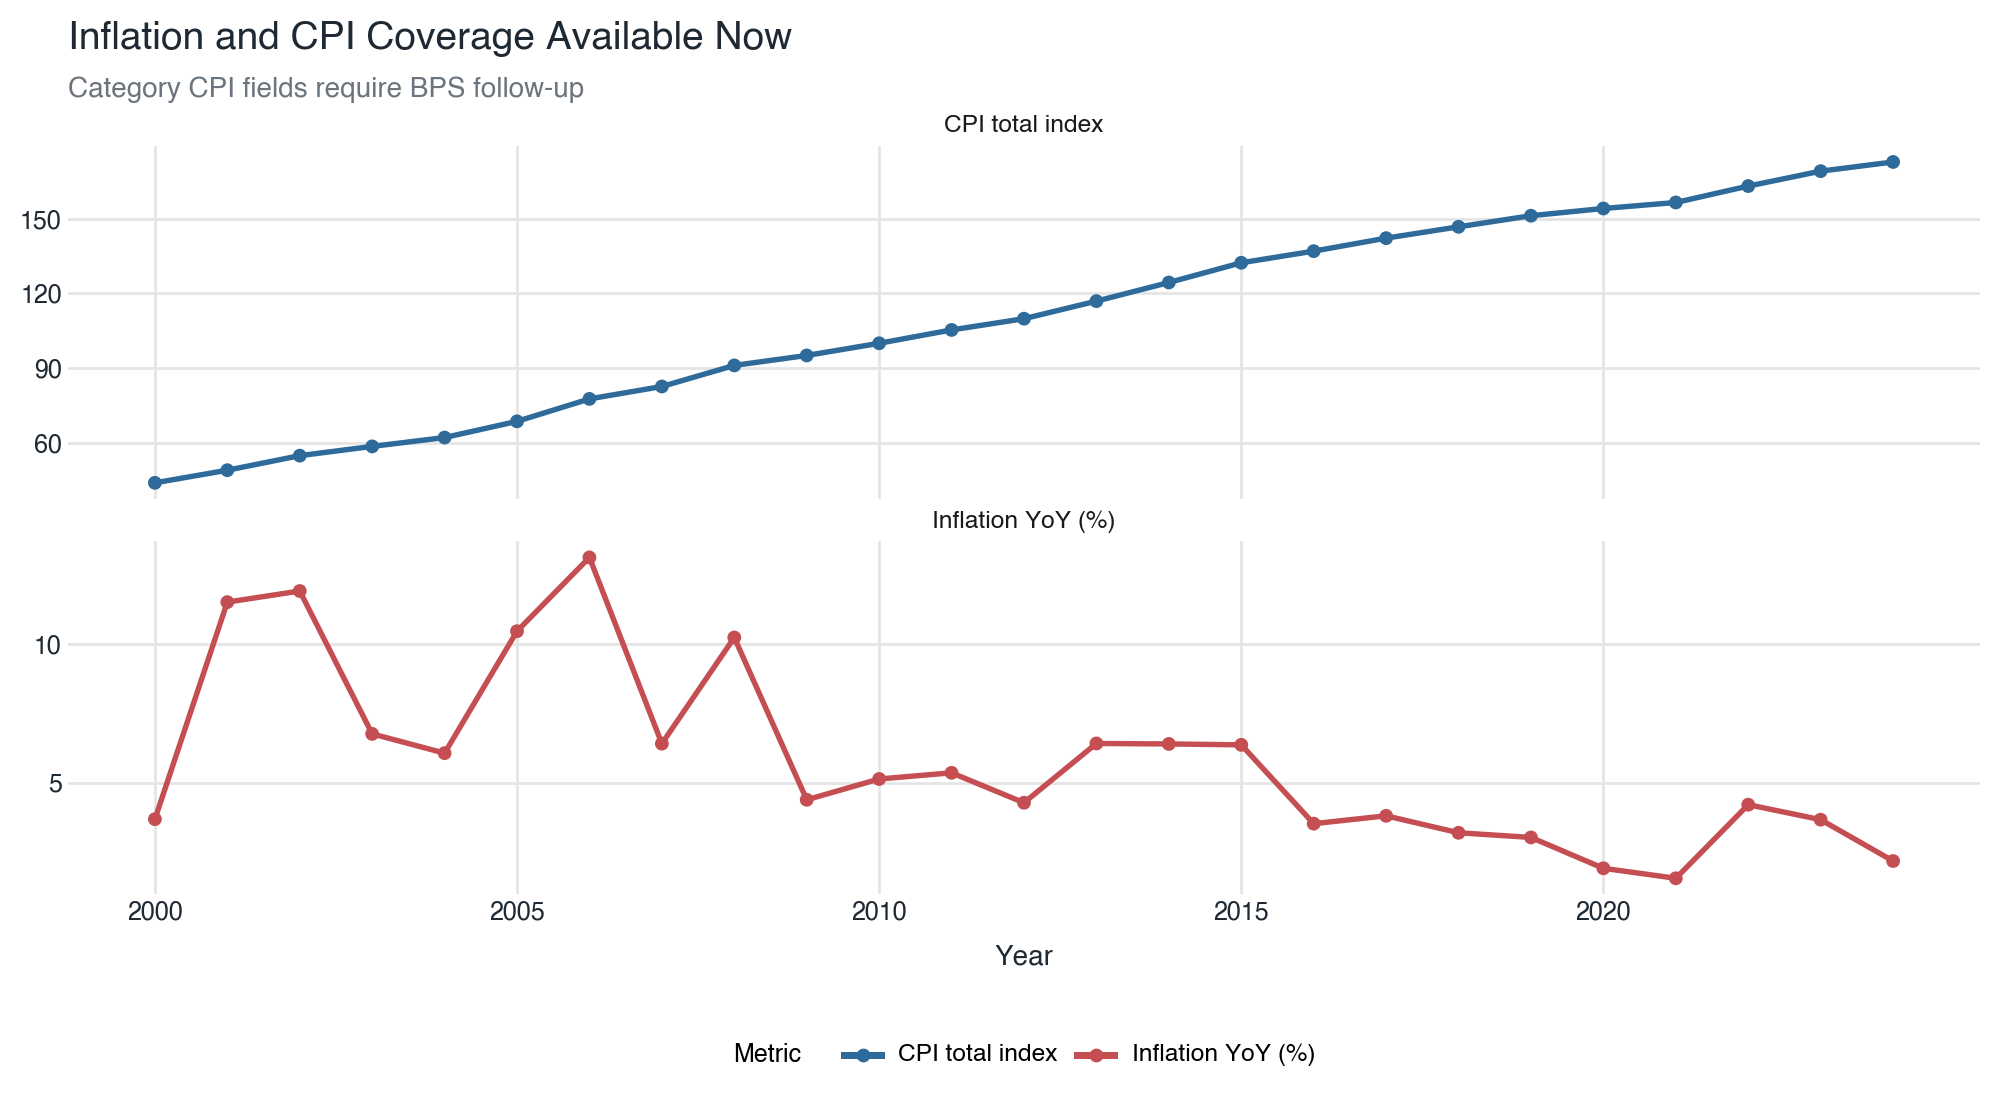

In [39]:
inflation_long = data['inflation'].melt(
    id_vars=['year'],
    value_vars=['cpi_total', 'inflation_yoy'],
    var_name='metric',
    value_name='value',
).dropna()

inflation_long['metric'] = inflation_long['metric'].map({
    'cpi_total': 'CPI total index',
    'inflation_yoy': 'Inflation YoY (%)',
})

(
    ggplot(inflation_long, aes('year', 'value', color='metric'))
    + geom_line(size=1.1)
    + geom_point(size=1.8)
    + facet_wrap('~ metric', scales='free_y', ncol=1)
    + scale_color_manual(values=[palette['blue'], palette['red']])
    + scale_x_continuous(breaks=list(range(2000, 2025, 5)))
    + labs(
        title='Inflation and CPI Coverage Available Now',
        subtitle='Category CPI fields require BPS follow-up',
        x='Year', y='', color='Metric'
    )
    + chart_theme()
)

## Inequality and Distribution Shares

The pipeline currently uses World Bank Gini and quintile distribution indicators. The distribution fields are treated as provisional for expenditure analysis because World Bank metadata may describe them as income or consumption shares depending on survey source.

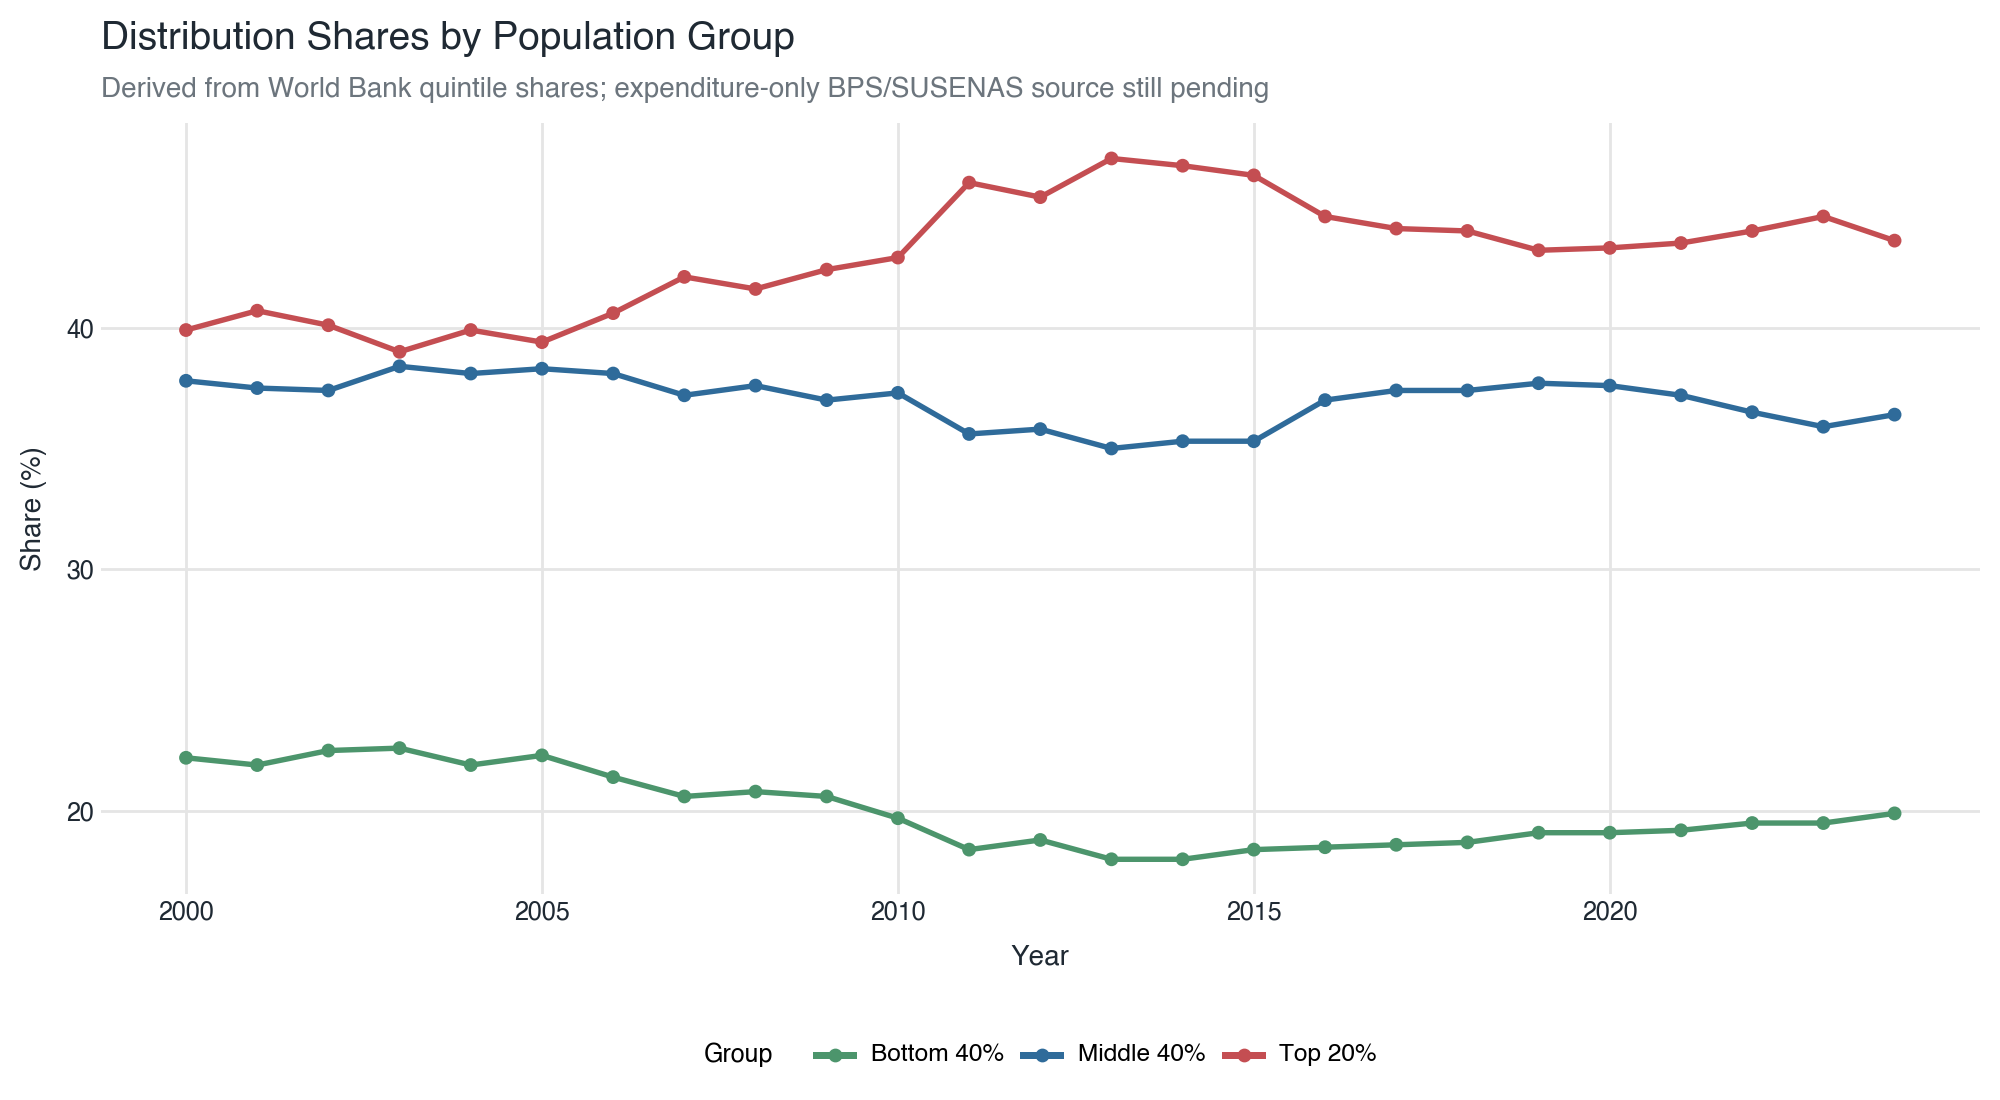

In [40]:
ineq_long = data['inequality'].melt(
    id_vars=['year'],
    value_vars=['expenditure_bottom40', 'expenditure_middle40', 'expenditure_top20'],
    var_name='group',
    value_name='share',
).dropna()

ineq_long['group'] = ineq_long['group'].map({
    'expenditure_bottom40': 'Bottom 40%',
    'expenditure_middle40': 'Middle 40%',
    'expenditure_top20': 'Top 20%',
})

(
    ggplot(ineq_long, aes('year', 'share', color='group'))
    + geom_line(size=1.1)
    + geom_point(size=1.8)
    + scale_color_manual(values=[palette['green'], palette['blue'], palette['red']])
    + scale_x_continuous(breaks=list(range(2000, 2025, 5)))
    + labs(
        title='Distribution Shares by Population Group',
        subtitle='Derived from World Bank quintile shares; expenditure-only BPS/SUSENAS source still pending',
        x='Year', y='Share (%)', color='Group'
    )
    + chart_theme()
)

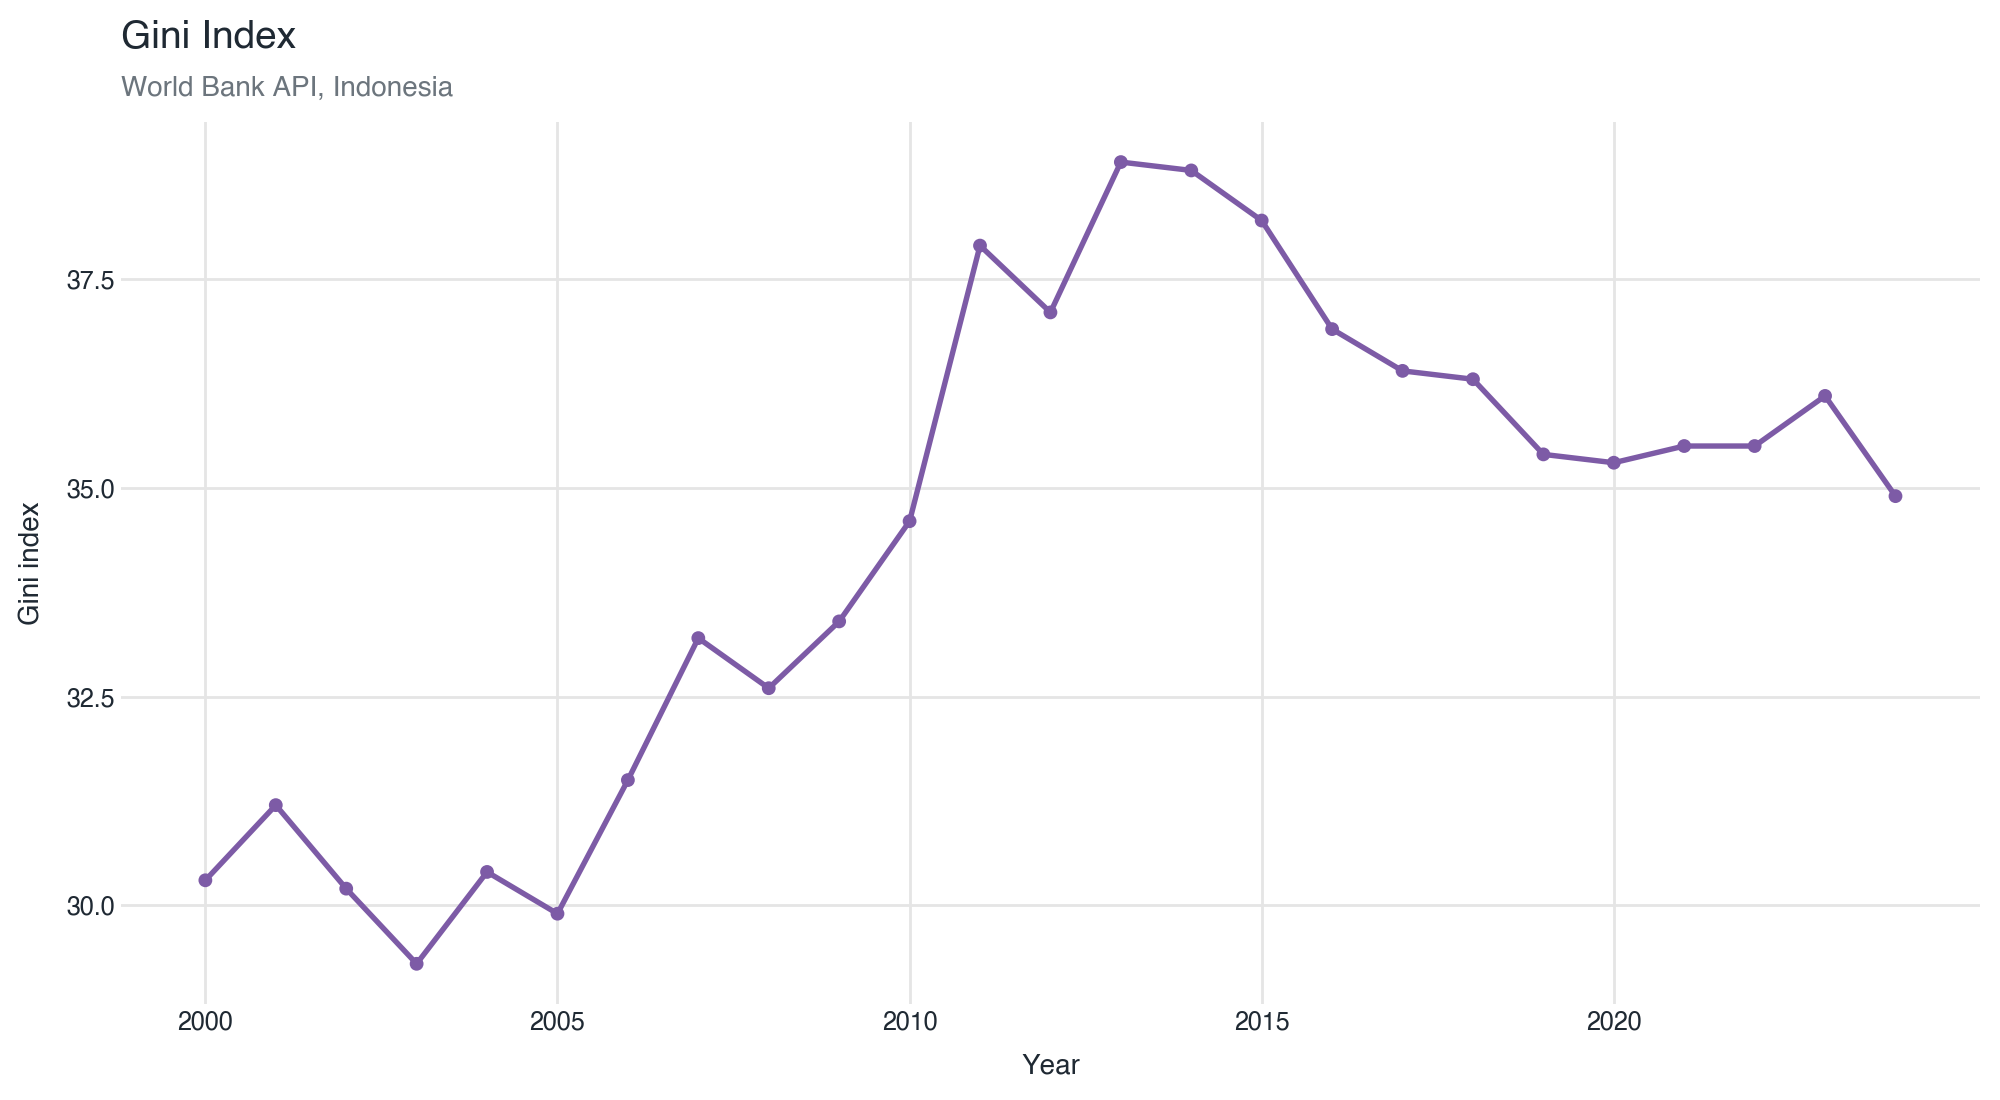

In [41]:
(
    ggplot(data['inequality'].dropna(subset=['gini_ratio']), aes('year', 'gini_ratio'))
    + geom_line(color=palette['purple'], size=1.1)
    + geom_point(color=palette['purple'], size=1.8)
    + scale_x_continuous(breaks=list(range(2000, 2025, 5)))
    + labs(
        title='Gini Index',
        subtitle='World Bank API, Indonesia',
        x='Year', y='Gini index'
    )
    + chart_theme()
)

## Poverty

Poverty fields are annual World Bank indicators: national poverty line headcount and international extreme poverty headcount.

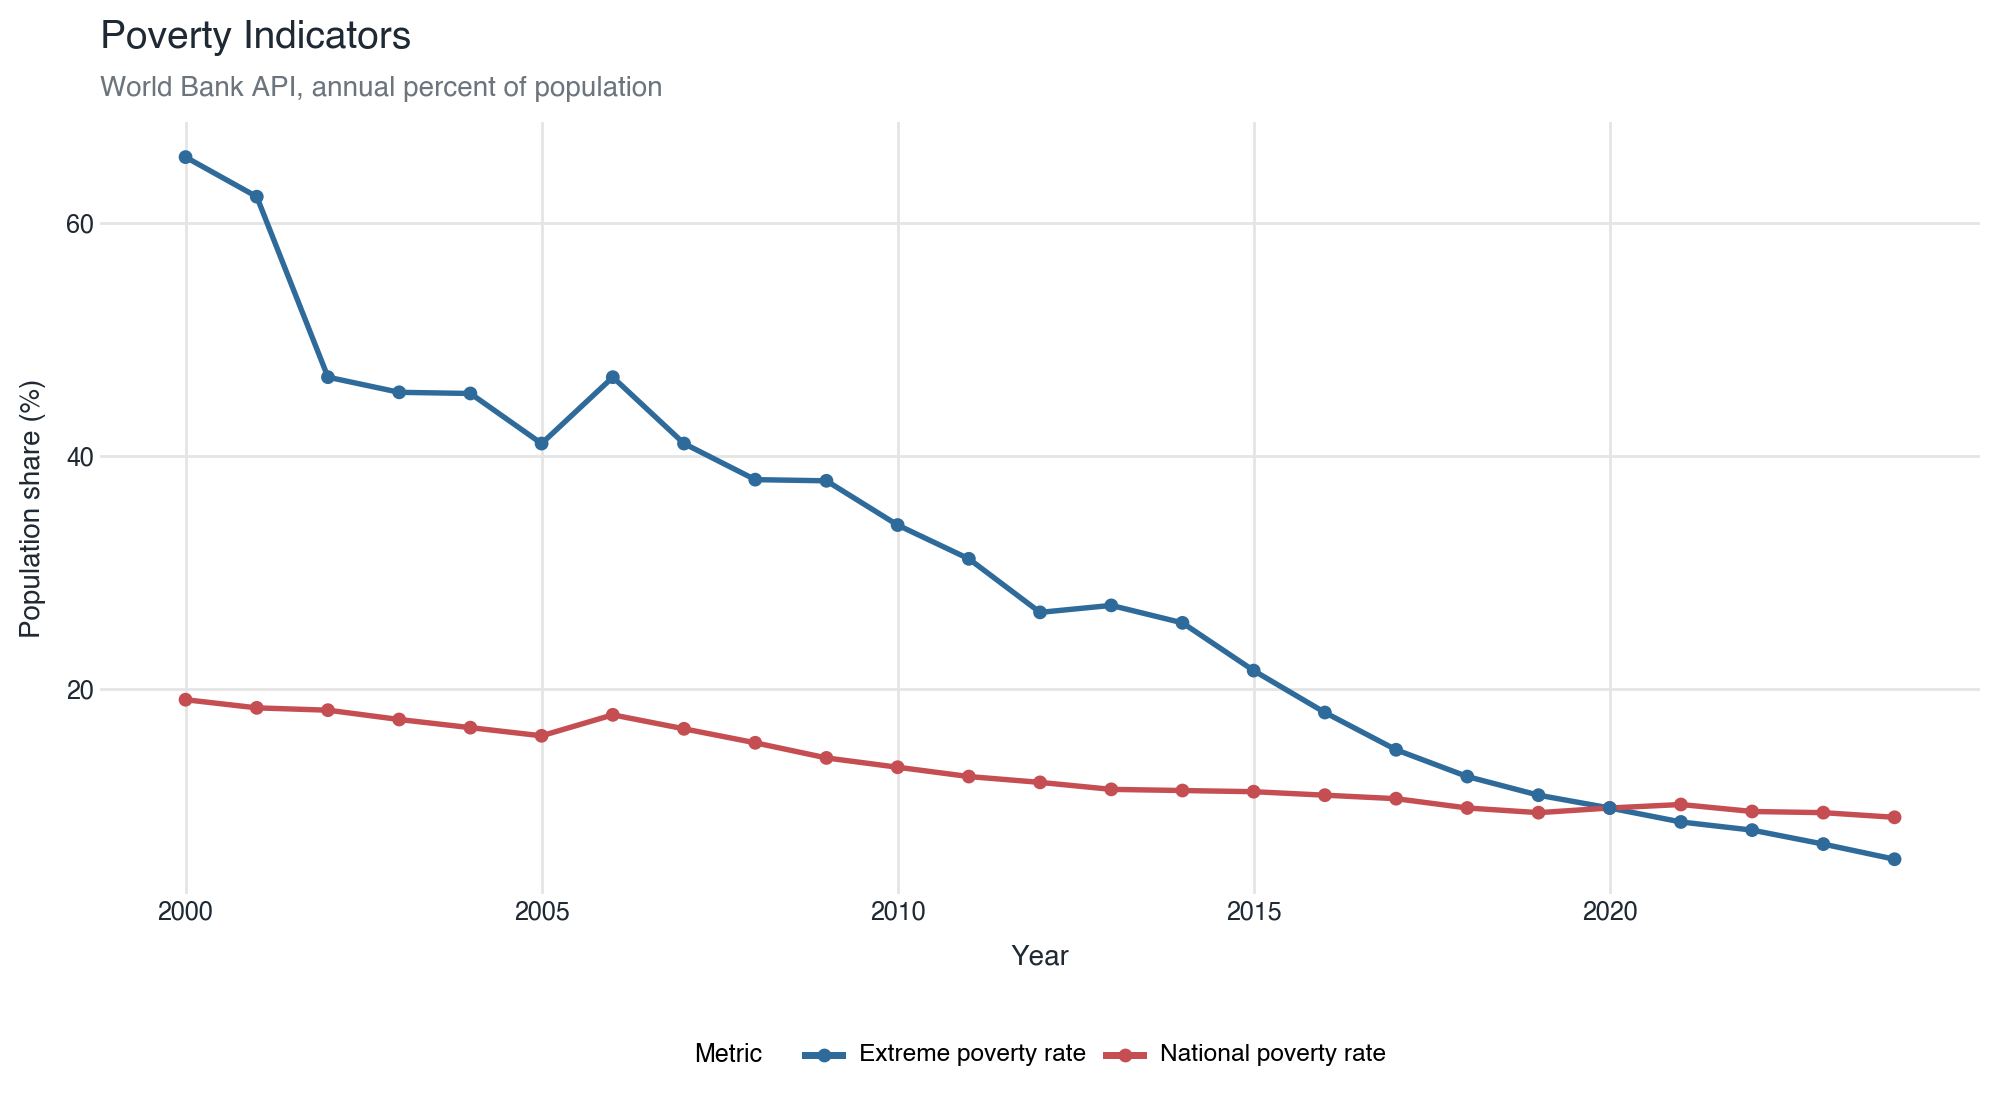

In [42]:
poverty_long = data['poverty'].melt(
    id_vars=['year'],
    value_vars=['poverty_rate', 'extreme_poverty_rate'],
    var_name='metric',
    value_name='value',
).dropna()

poverty_long['metric'] = poverty_long['metric'].map({
    'poverty_rate': 'National poverty rate',
    'extreme_poverty_rate': 'Extreme poverty rate',
})

(
    ggplot(poverty_long, aes('year', 'value', color='metric'))
    + geom_line(size=1.1)
    + geom_point(size=1.8)
    + scale_color_manual(values=[palette['blue'], palette['red']])
    + scale_x_continuous(breaks=list(range(2000, 2025, 5)))
    + labs(
        title='Poverty Indicators',
        subtitle='World Bank API, annual percent of population',
        x='Year', y='Population share (%)', color='Metric'
    )
    + chart_theme()
)

## Labor Market

The available labor fields cover total unemployment, youth unemployment, and vulnerable employment. Wage and informal employment fields remain BPS/ILOSTAT follow-up items.

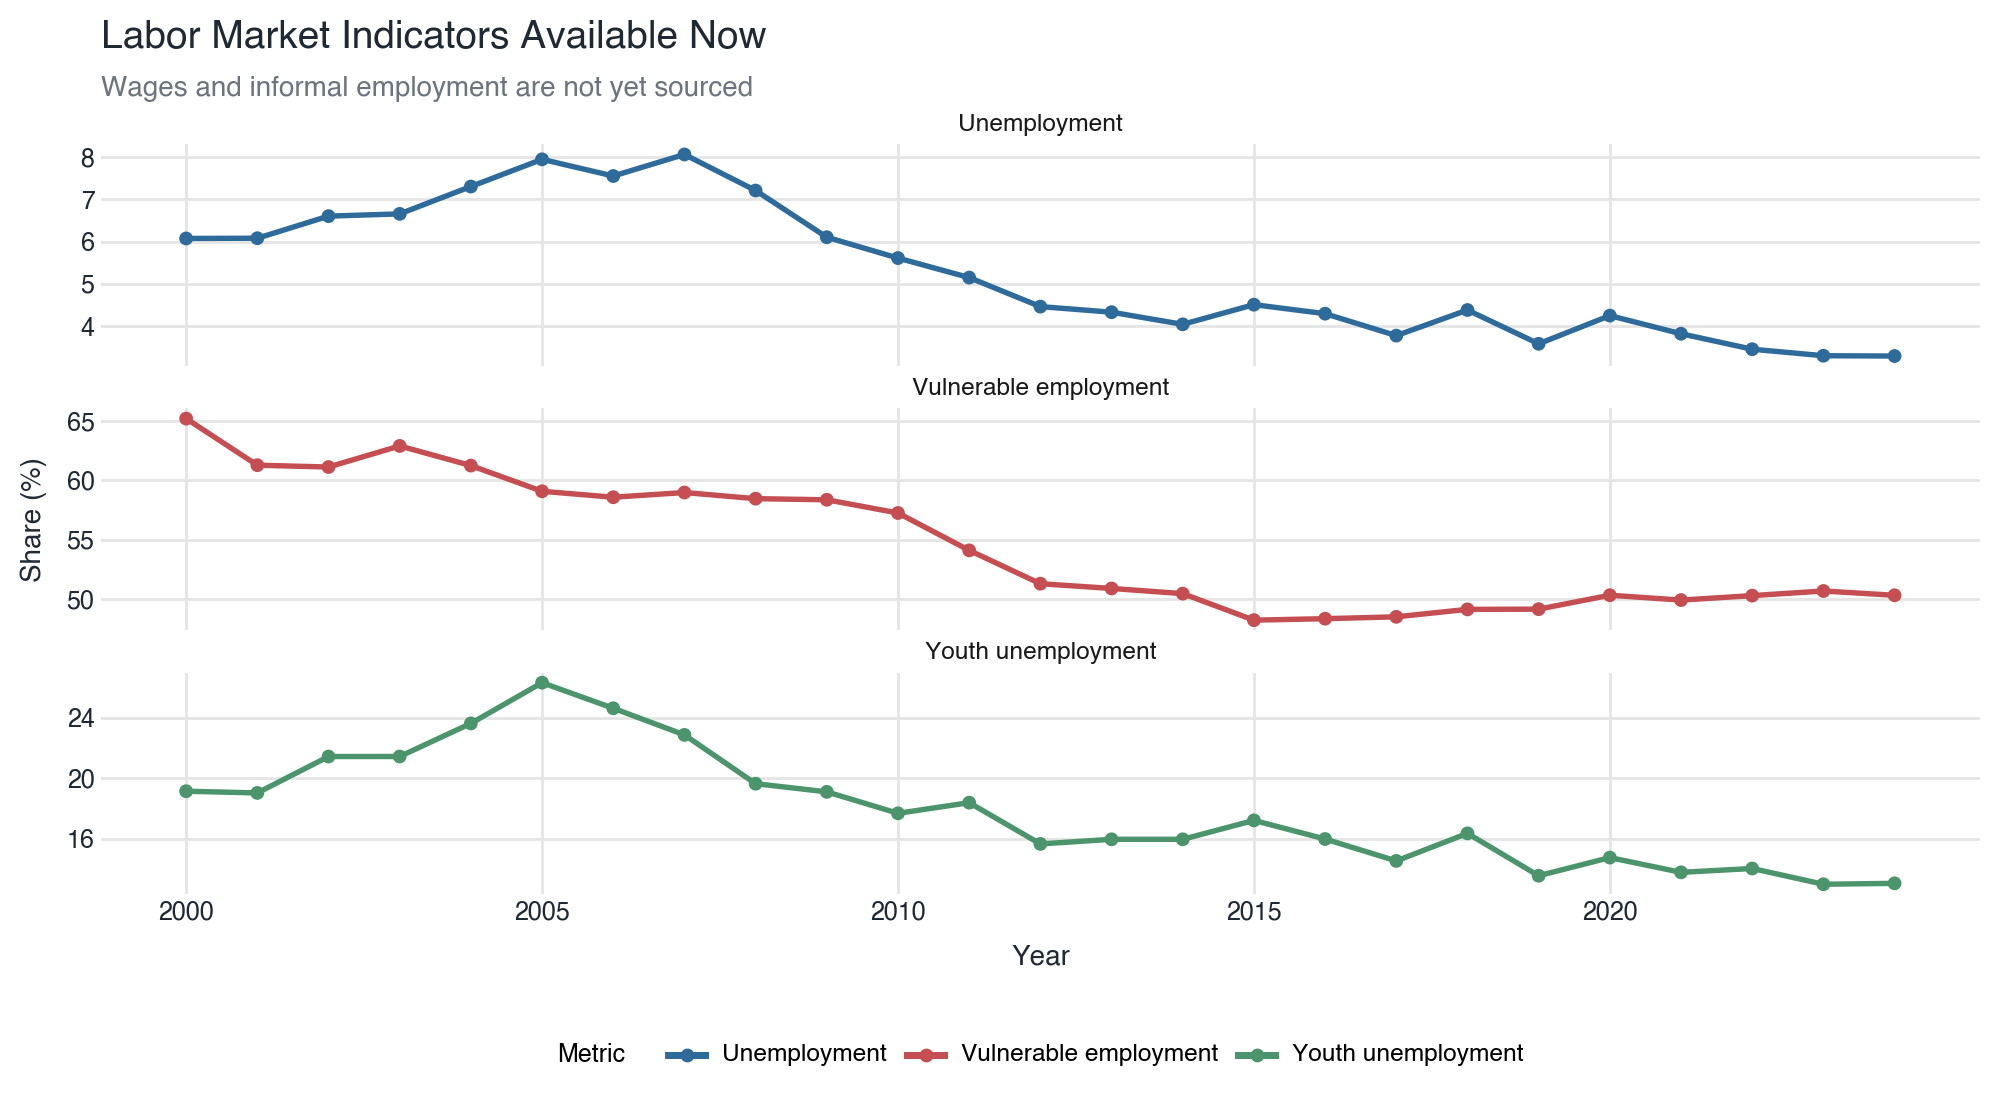

In [43]:
labor_long = data['labor'].melt(
    id_vars=['year'],
    value_vars=['unemployment_rate', 'youth_unemployment', 'vulnerable_employment_share'],
    var_name='metric',
    value_name='value',
).dropna()

labor_long['metric'] = labor_long['metric'].map({
    'unemployment_rate': 'Unemployment',
    'youth_unemployment': 'Youth unemployment',
    'vulnerable_employment_share': 'Vulnerable employment',
})

(
    ggplot(labor_long, aes('year', 'value', color='metric'))
    + geom_line(size=1.1)
    + geom_point(size=1.8)
    + facet_wrap('~ metric', scales='free_y', ncol=1)
    + scale_color_manual(values=[palette['blue'], palette['red'], palette['green']])
    + scale_x_continuous(breaks=list(range(2000, 2025, 5)))
    + labs(
        title='Labor Market Indicators Available Now',
        subtitle='Wages and informal employment are not yet sourced',
        x='Year', y='Share (%)', color='Metric'
    )
    + chart_theme()
)

## Cost of Living Placeholder

The cost-of-living schema exists, but only total CPI is currently populated. This chart is mostly a reminder that this dataset needs BPS commodity/category sources before substantive EDA.

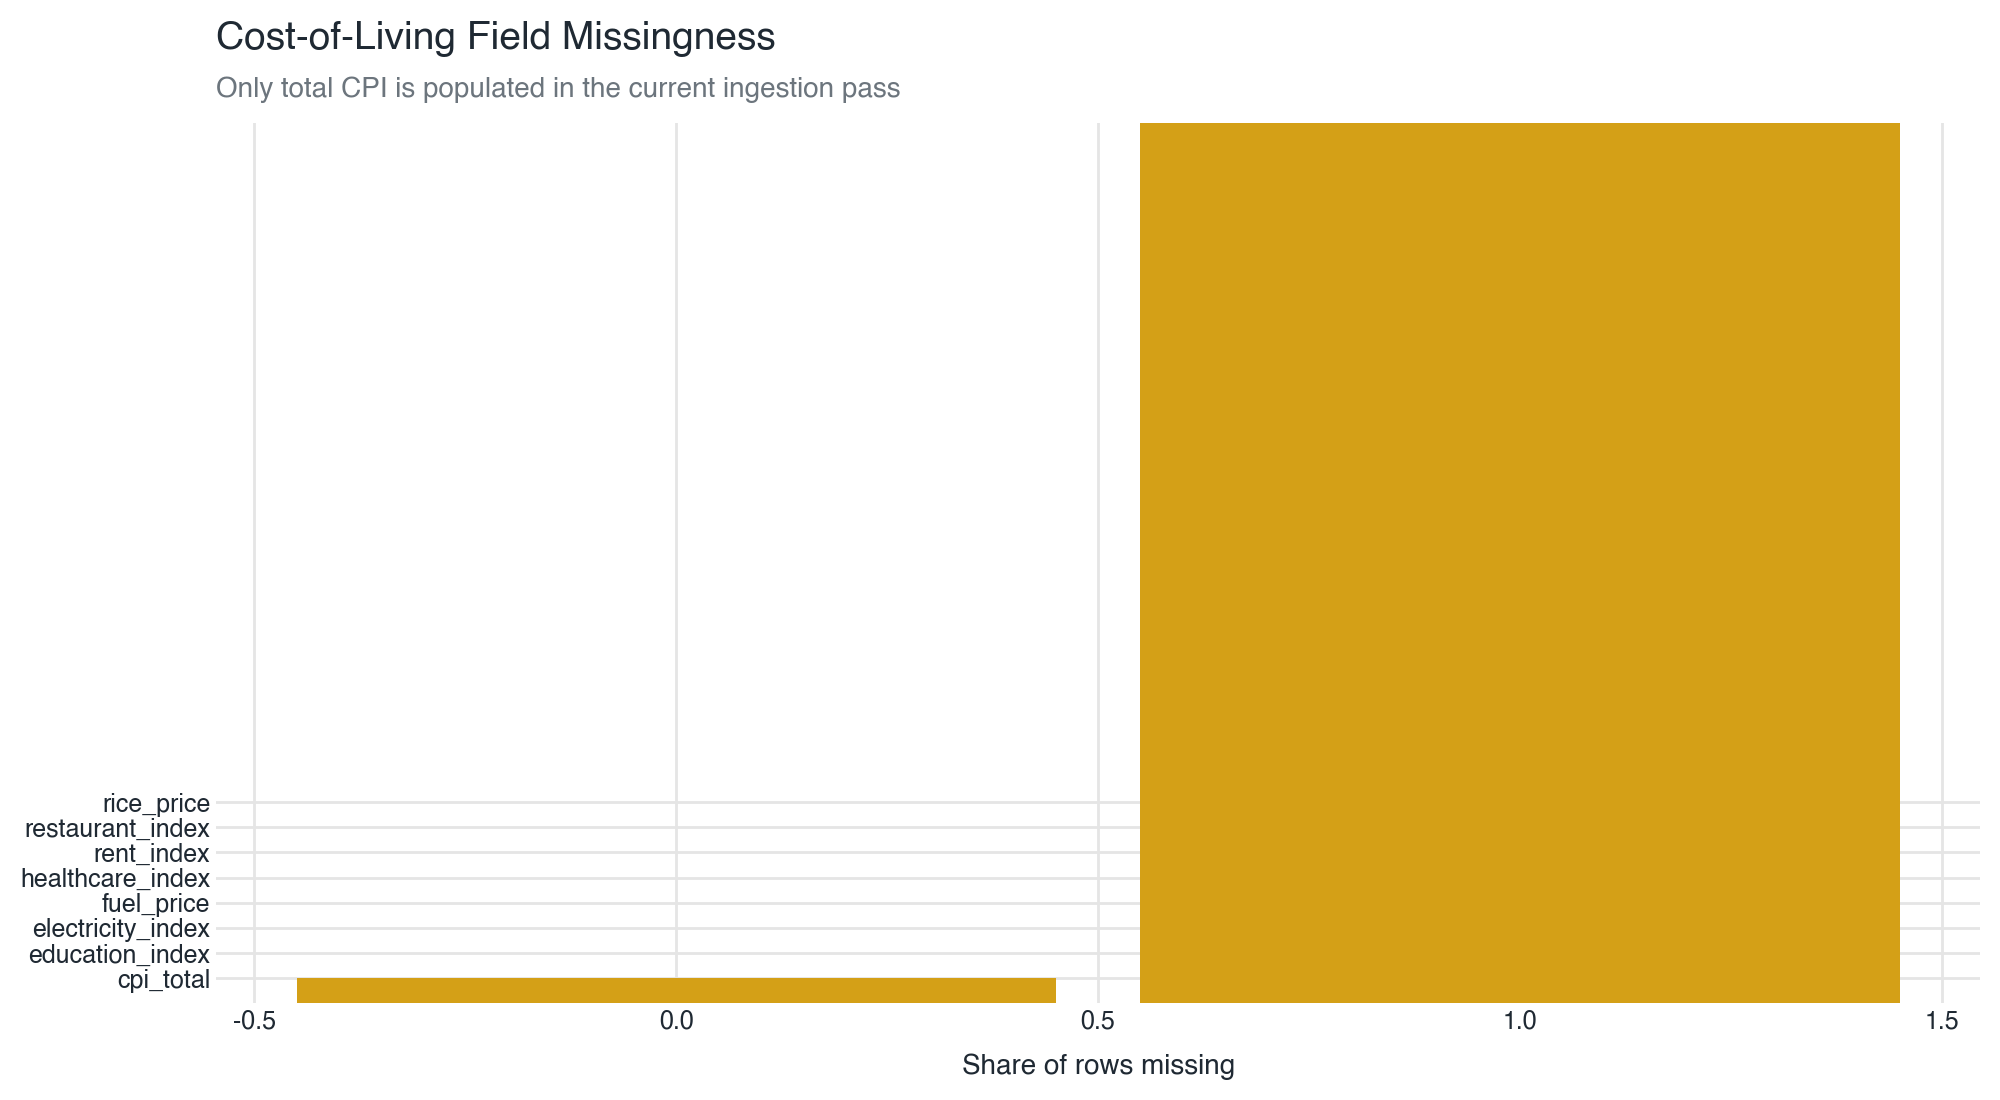

In [44]:
col = data['cost_of_living']
missing_cost = col[[c for c in col.columns if c not in ['year', 'source']]].isna().mean().reset_index()
missing_cost.columns = ['field', 'missing_rate']

(
    ggplot(missing_cost, aes('missing_rate', 'field'))
    + geom_col(fill=palette['gold'])
    + labs(
        title='Cost-of-Living Field Missingness',
        subtitle='Only total CPI is populated in the current ingestion pass',
        x='Share of rows missing', y=''
    )
    + chart_theme()
)

## Starter Combined Dataset

This final section creates a wide analytical table by joining all currently available annual fields. It is useful for future EDA, but should not be interpreted as a finalized analysis dataset until BPS gaps are addressed.

In [45]:
combined = data['gdp'].drop(columns=['source']).copy()
for name in ['inflation', 'inequality', 'poverty', 'labor', 'cost_of_living']:
    df = data[name].drop(columns=['source']).copy()
    duplicate_cols = [c for c in df.columns if c != 'year' and c in combined.columns]
    df = df.drop(columns=duplicate_cols)
    combined = combined.merge(df, on='year', how='outer')

combined = combined.sort_values('year').reset_index(drop=True)
combined.head()

,year,gdp_growth,real_gdp_per_capita,nominal_gdp_per_capita,cpi_total,inflation_yoy,cpi_food,cpi_transport,cpi_housing,cpi_education,cpi_healthcare,cpi_restaurant,gini_ratio,expenditure_bottom40,expenditure_middle40,expenditure_top20,poverty_rate,extreme_poverty_rate,unemployment_rate,youth_unemployment,avg_wage,real_wage_growth,informal_employment_share,vulnerable_employment_share,rice_price,fuel_price,electricity_index,rent_index,education_index,healthcare_index,restaurant_index
0,2000,4.920,"1,828.103",763.711,44.016,3.689,NaN,NaN,NaN,NaN,NaN,NaN,30.300,22.200,37.800,39.900,19.100,65.700,6.077,19.147,NaN,NaN,NaN,65.222,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2001,3.643,"1,868.592",732.307,49.078,11.500,NaN,NaN,NaN,NaN,NaN,NaN,31.200,21.900,37.500,40.700,18.400,62.300,6.082,19.035,NaN,NaN,NaN,61.287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2002,4.499,"1,926.374",881.003,54.918,11.900,NaN,NaN,NaN,NaN,NaN,NaN,30.200,22.500,37.400,40.100,18.200,46.800,6.604,21.434,NaN,NaN,NaN,61.132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2003,4.780,"1,991.918","1,043.211",58.629,6.757,NaN,NaN,NaN,NaN,NaN,NaN,29.300,22.600,38.400,39.000,17.400,45.500,6.657,21.436,NaN,NaN,NaN,62.912,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2004,5.031,"2,065.706","1,126.840",62.185,6.064,NaN,NaN,NaN,NaN,NaN,NaN,30.400,21.900,38.100,39.900,16.700,45.400,7.303,23.617,NaN,NaN,NaN,61.254,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
combined.describe(include='all').T[['count', 'mean', 'std', 'min', 'max']]

,count,mean,std,min,max
year,25.000,"2,012.000",7.360,"2,000.000","2,024.000"
gdp_growth,25.000,4.890,1.601,-2.066,6.345
real_gdp_per_capita,25.000,"2,962.378",801.870,"1,828.103","4,367.863"
nominal_gdp_per_capita,25.000,"2,881.795","1,390.306",732.307,"4,925.430"
cpi_total,25.000,110.616,40.884,44.016,172.741
inflation_yoy,25.000,5.821,3.246,1.560,13.109
cpi_food,0.000,NaN,NaN,NaN,NaN
cpi_transport,0.000,NaN,NaN,NaN,NaN
cpi_housing,0.000,NaN,NaN,NaN,NaN
cpi_education,0.000,NaN,NaN,NaN,NaN


## Next EDA Tasks After BPS Is Available

- Add category CPI charts once BPS CPI table IDs are mapped.
- Add rice/fuel/electricity/LPG/rent price charts once official annual sources are ingested.
- Replace provisional distribution shares with BPS/SUSENAS expenditure-only distribution if available.
- Add wage and informal employment charts once BPS or ILOSTAT source series are confirmed.